# VGG16 Transfer Learning — DDSM Mammography

**Project:** Deep Learning for Breast Cancer Detection  
**Dataset:** DDSM Mammography (`skooch/ddsm-mammography`) — TFRecords  
**Task:** Binary classification — Negative vs Positive (abnormal)  
**Framework:** TensorFlow / Keras — Kaggle  
**Base Model:** VGG16 pretrained on ImageNet

---

## Strategy

VGG16 was trained on ImageNet (natural photos), not mammograms. The fine-tuning strategy used here is:

1. **Phase 1 — Feature extraction:** Freeze all VGG16 layers, train only the new classification head. This lets the head learn to interpret VGG16 features without destroying pretrained weights.
2. **Phase 2 — Fine-tuning:** Unfreeze the top conv blocks of VGG16 and train end-to-end at a very low learning rate. This adapts the high-level features to mammography.

**Data balancing:** The training pipeline oversamples the positive (cancer) class to a 50/50 split using `tf.data.Dataset.sample_from_datasets`. Val and test sets are left at the natural ~86/14 distribution to give honest evaluation metrics.

## Setup and Data Pipeline

In [2]:
import os
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tensorflow.keras import models, layers, Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)

# ── Kaggle paths ──────────────────────────────────────────────────────────────
DATA_DIR  = '/kaggle/input/datasets/skooch/ddsm-mammography'
SAVE_PATH = '/kaggle/working'
# ─────────────────────────────────────────────────────────────────────────────

TARGET_SIZE     = (224, 224)
BATCH_SIZE      = 32
CLAHE_PROCESSOR = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

FEATURE_DICT = {
    'label':        tf.io.FixedLenFeature([], tf.int64),
    'label_normal': tf.io.FixedLenFeature([], tf.int64),
    'image':        tf.io.FixedLenFeature([], tf.string),
}

def parse(serialized_example):
    features = tf.io.parse_single_example(serialized_example, FEATURE_DICT)
    label    = features['label_normal']
    image    = tf.io.decode_raw(features['image'], tf.uint8)
    image    = tf.reshape(image, [299, 299, 1])

    def enhance_and_resize(img):
        img = img[:, :, 0]
        img = cv2.GaussianBlur(img, ksize=(3, 3), sigmaX=1)
        img = CLAHE_PROCESSOR.apply(img)
        img = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)
        img = cv2.merge([img, img, img])
        img = img.astype(np.float32) / 255.0
        return img

    image = tf.numpy_function(enhance_and_resize, [image], tf.float32)
    image.set_shape([224, 224, 3])
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.85, upper=1.15)
    image = tf.image.random_saturation(image, lower=0.85, upper=1.15)
    image = tf.image.random_hue(image, max_delta=0.05)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

# Verify files
print('Checking dataset files...')
for i in range(5):
    p = os.path.join(DATA_DIR, f'training10_{i}', f'training10_{i}.tfrecords')
    print(f'  training10_{i}.tfrecords : {"FOUND" if os.path.exists(p) else "MISSING"}')

train_files = [
    os.path.join(DATA_DIR, f'training10_{i}', f'training10_{i}.tfrecords')
    for i in range(4)
]
file_4 = os.path.join(DATA_DIR, 'training10_4', 'training10_4.tfrecords')

total_file4 = sum(1 for _ in tf.data.TFRecordDataset(file_4))
val_size    = total_file4 // 2

# ── Balanced training pipeline ────────────────────────────────────────────────
def is_positive(image, label):
    return tf.equal(label, 1)

def is_negative(image, label):
    return tf.equal(label, 0)

pos_dataset = (
    tf.data.TFRecordDataset(train_files)
    .map(parse, num_parallel_calls=tf.data.AUTOTUNE)
    .filter(is_positive)
    .repeat()
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
)

neg_dataset = (
    tf.data.TFRecordDataset(train_files)
    .map(parse, num_parallel_calls=tf.data.AUTOTUNE)
    .filter(is_negative)
    .repeat()
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
)

train_dataset = (
    tf.data.Dataset.sample_from_datasets(
        [pos_dataset, neg_dataset],
        weights=[0.5, 0.5]
    )
    .shuffle(2000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.TFRecordDataset(file_4)
    .map(parse, num_parallel_calls=tf.data.AUTOTUNE)
    .take(val_size)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.TFRecordDataset(file_4)
    .map(parse, num_parallel_calls=tf.data.AUTOTUNE)
    .skip(val_size)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Mild class weight — balanced pipeline does the heavy lifting
class_weight_dict = {0: 1.0, 1: 1.5}
STEPS_PER_EPOCH  = 1398  # matches original unbalanced epoch length

results = {}

print('\nPipeline ready.')
print(f'Val   : file 4 first half  ({val_size:,} images)')
print(f'Test  : file 4 second half ({total_file4 - val_size:,} images)')
print(f'Class weights : {class_weight_dict}')
print(f'Steps/epoch   : {STEPS_PER_EPOCH}')

2026-03-22 13:18:51.537208: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774185531.738790      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774185531.794526      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774185532.263554      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774185532.263594      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774185532.263596      55 computation_placer.cc:177] computation placer alr

Checking dataset files...
  training10_0.tfrecords : FOUND
  training10_1.tfrecords : FOUND
  training10_2.tfrecords : FOUND
  training10_3.tfrecords : FOUND
  training10_4.tfrecords : FOUND


I0000 00:00:1774185557.922890      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774185557.928663      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Pipeline ready.
Val   : file 4 first half  (5,588 images)
Test  : file 4 second half (5,589 images)
Class weights : {0: 1.0, 1: 1.5}
Steps/epoch   : 1398


## Evaluation Function

In [3]:
def evaluate_experiment(exp_name, model_path, history, test_dataset,
                        save_path, results):
    print(f'\nLoading {model_path}...')
    model = tf.keras.models.load_model(model_path)

    y_pred_probs, y_true = [], []
    for images, labels in test_dataset:
        preds = model.predict(images, verbose=0).flatten()
        y_pred_probs.extend(preds)
        y_true.extend(labels.numpy())

    y_pred_probs = np.array(y_pred_probs)
    y_true       = np.array(y_true)
    y_pred       = (y_pred_probs >= 0.5).astype(int)

    print(f'True:      {np.unique(y_true, return_counts=True)}')
    print(f'Predicted: {np.unique(y_pred, return_counts=True)}')
    print('\n' + '='*55)
    print(f'{exp_name.upper()} -- CLASSIFICATION REPORT')
    print('='*55)
    print(classification_report(y_true, y_pred,
                                 target_names=['Negative', 'Positive']))

    cm             = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr, tpr, _    = roc_curve(y_true, y_pred_probs)
    roc_auc        = auc(fpr, tpr)
    accuracy       = (tp + tn) / len(y_true)
    sensitivity    = tp / (tp + fn)
    specificity    = tn / (tn + fp)
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred_probs)
    pr_auc         = auc(recall_vals, precision_vals)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{exp_name} -- Evaluation', fontsize=14, fontweight='bold')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[2].plot(recall_vals, precision_vals, color='darkorange', lw=2,
                 label=f'PR-AUC = {pr_auc:.3f}')
    axes[2].axhline(y=sum(y_true)/len(y_true), color='k',
                    linestyle='--', lw=1, label='Baseline')
    axes[2].set_title('Precision-Recall Curve')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    plt.tight_layout()
    fname = exp_name.lower().replace(' ', '_').replace('-', '').replace('+', '')
    plt.savefig(f'{save_path}/{fname}_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Evaluation plot saved')

    if history is not None:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'{exp_name} -- Training History', fontsize=14, fontweight='bold')
        axes[0].plot(history.history['loss'],     label='Train')
        axes[0].plot(history.history['val_loss'], label='Val')
        axes[0].set_title('Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].legend()
        axes[0].grid(alpha=0.3)
        axes[1].plot(history.history['auc'],     label='Train')
        axes[1].plot(history.history['val_auc'], label='Val')
        axes[1].set_title('AUC')
        axes[1].set_xlabel('Epoch')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{save_path}/{fname}_history.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('History plot saved')

    print(f'\n{"="*55}')
    print(f'{exp_name.upper()} SUMMARY')
    print(f'{"="*55}')
    print(f'Accuracy:                {accuracy:.3f}')
    print(f'ROC-AUC:                 {roc_auc:.3f}')
    print(f'Sensitivity (Positive):  {sensitivity:.3f}')
    print(f'Specificity (Negative):  {specificity:.3f}')

    results[exp_name] = {
        'accuracy':    round(accuracy, 3),
        'roc_auc':     round(roc_auc, 3),
        'sensitivity': round(sensitivity, 3),
        'specificity': round(specificity, 3)
    }

    print('\nRESULTS TRACKER')
    print('='*55)
    for exp, m in results.items():
        print(f"{exp}: Acc={m['accuracy']} | AUC={m['roc_auc']} | "
              f"Sens={m['sensitivity']} | Spec={m['specificity']}")

    return results

results = {}
print('evaluate_experiment() defined.')

evaluate_experiment() defined.


## VGG16 — Phase 1: Feature Extraction (Frozen Base)

Load VGG16 pretrained on ImageNet without its top classification layers.
All VGG16 layers are frozen — only the new head is trained.

The head uses GlobalAveragePooling2D instead of Flatten to reduce parameters
and overfitting risk, followed by two dense layers with BatchNorm and Dropout.

In [4]:
# ── Load VGG16 base (no top, ImageNet weights) ───────────────────────────────
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze entire base for Phase 1
base_model.trainable = False

print(f'VGG16 loaded. Trainable layers: {sum(1 for l in base_model.layers if l.trainable)}')
print(f'Total VGG16 layers: {len(base_model.layers)}')

# ── Build classification head ─────────────────────────────────────────────────
inputs  = layers.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)  # training=False keeps BN frozen
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.5)(x)
x       = layers.Dense(64, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_vgg_p1 = Model(inputs, outputs, name='vgg16_phase1_frozen')
model_vgg_p1.summary()

model_vgg_p1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

checkpoint_p1 = ModelCheckpoint(
    f'{SAVE_PATH}/vgg16_phase1_best.keras',
    monitor='val_auc', mode='max',
    save_best_only=True, verbose=1
)
early_stop_p1 = EarlyStopping(
    monitor='val_auc', patience=10,
    restore_best_weights=True, verbose=1
)
reduce_lr_p1 = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=5, min_lr=1e-7, verbose=1
)

print('\nPhase 1 training started — frozen VGG16, head only...')
history_p1 = model_vgg_p1.fit(
    train_dataset,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=30,
    validation_data=val_dataset,
    callbacks=[checkpoint_p1, early_stop_p1, reduce_lr_p1],
    class_weight=class_weight_dict,
    verbose=1
)

models.save_model(model_vgg_p1, f'{SAVE_PATH}/vgg16_phase1_end.keras')
print('Phase 1 complete.')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 loaded. Trainable layers: 0
Total VGG16 layers: 19


Model: "vgg16_phase1_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,863,809 (56.70 MB)

 Trainable params: 148,481 (580.00 KB)

...

   1/1398 ━━━━━━━━━━━━━━━━━━━━ 11:56:08 31s/step - accuracy: 0.5312 - auc: 0.5824 - loss: 0.9982 - precision: 0.5500 - recall: 0.6471

I0000 00:00:1774185600.808786     104 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1398/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.6429 - auc: 0.6952 - loss: 0.8661 - precision: 0.6302 - recall: 0.6817
Epoch 1: val_auc improved from -inf to 0.87049, saving model to /kaggle/working/vgg16_phase1_best.keras


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1398/1398 ━━━━━━━━━━━━━━━━━━━━ 371s 244ms/step - accuracy: 0.6429 - auc: 0.6953 - loss: 0.8660 - precision: 0.6302 - recall: 0.6818 - val_accuracy: 0.5957 - val_auc: 0.8705 - val_loss: 0.7466 - val_precision: 0.2300 - val_recall: 0.9296 - learning_rate: 1.0000e-04
Epoch 2/30
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.7297 - auc: 0.8058 - loss: 0.6668 - precision: 0.6975 - recall: 0.8181
Epoch 2: val_auc improved from 0.87049 to 0.87582, saving model to /kaggle/working/vgg16_phase1_best.keras
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 328s 235ms/step - accuracy: 0.7297 - auc: 0.8058 - loss: 0.6668 - precision: 0.6975 - recall: 0.8181 - val_accuracy: 0.6471 - val_auc: 0.8758 - val_loss: 0.6599 - val_precision: 0.2567 - val_recall: 0.9380 - learning_rate: 1.0000e-04
Epoch 3/30
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.7414 - auc: 0.8253 - loss: 0.6280 - precision: 0.7037 - recall: 0.8400
Epoch 3: val_auc improved from 0.87582 to 0.88593, saving model to /kaggle/workin


Loading /kaggle/working/vgg16_phase1_best.keras...
True:      (array([0, 1]), array([4855,  734]))
Predicted: (array([0, 1]), array([3368, 2221]))

VGG16 PHASE 1 - FROZEN BASE -- CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.99      0.68      0.81      4855
    Positive       0.31      0.94      0.47       734

    accuracy                           0.72      5589
   macro avg       0.65      0.81      0.64      5589
weighted avg       0.90      0.72      0.76      5589



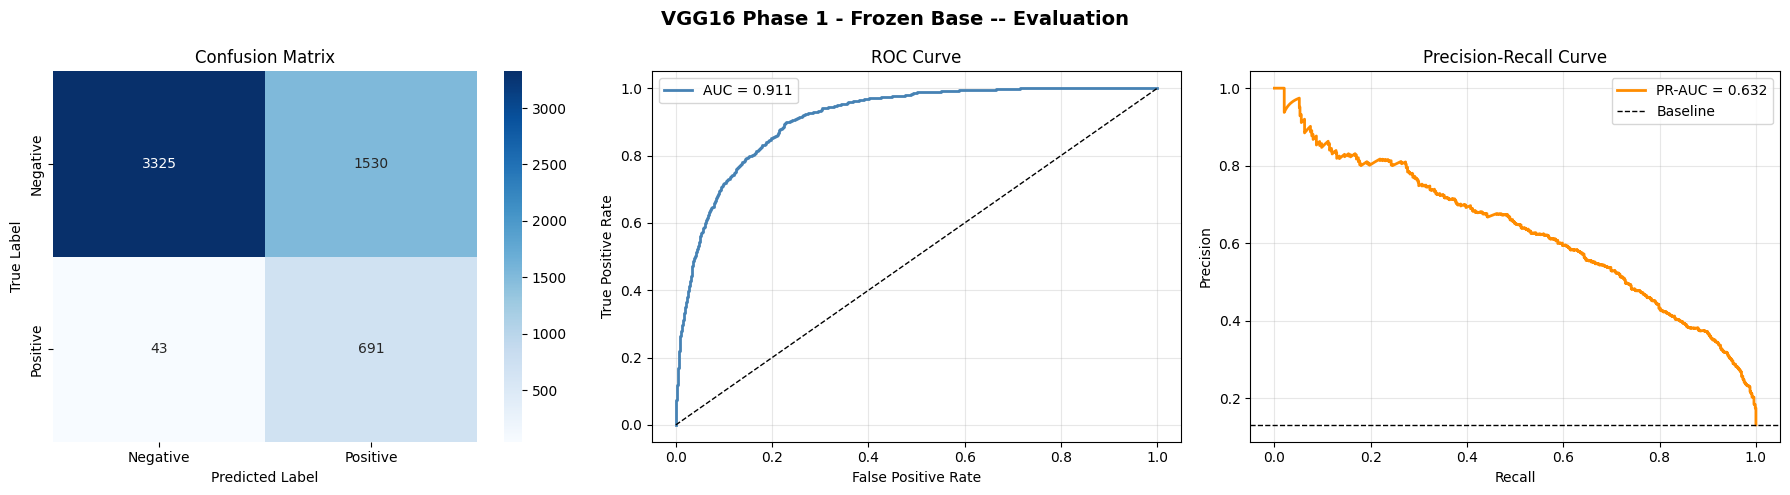

Evaluation plot saved


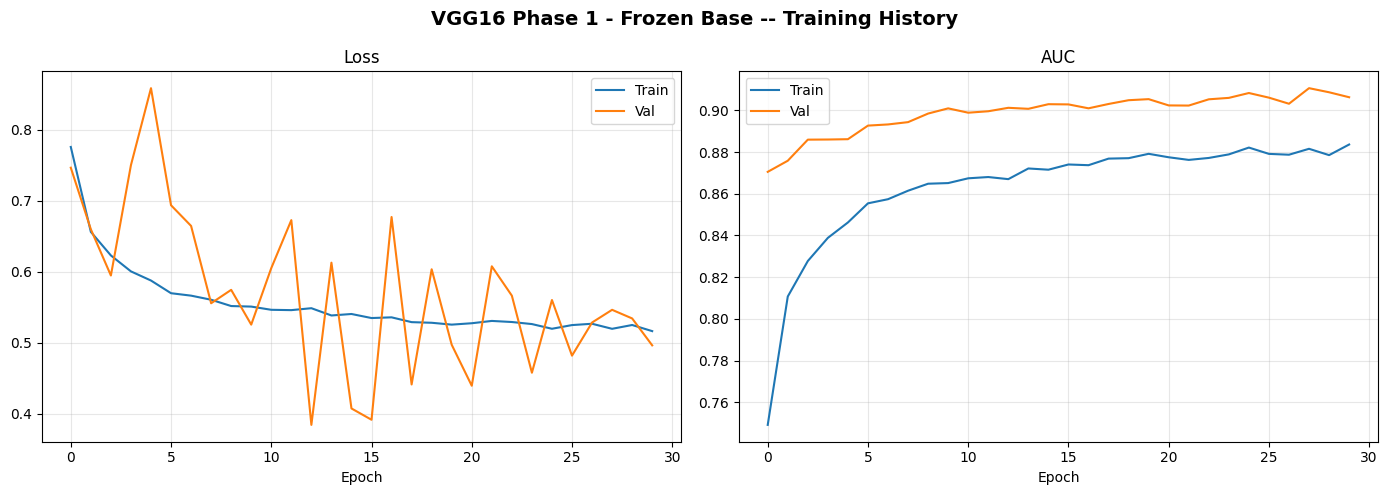

History plot saved

VGG16 PHASE 1 - FROZEN BASE SUMMARY
Accuracy:                0.719
ROC-AUC:                 0.911
Sensitivity (Positive):  0.941
Specificity (Negative):  0.685

RESULTS TRACKER
VGG16 Phase 1 - Frozen Base: Acc=0.719 | AUC=0.911 | Sens=0.941 | Spec=0.685


In [5]:
results = evaluate_experiment('VGG16 Phase 1 - Frozen Base',
    f'{SAVE_PATH}/vgg16_phase1_best.keras', history_p1,
    test_dataset, SAVE_PATH, results)

## VGG16 — Phase 2: Fine-Tuning (Unfreeze Top Conv Blocks)

The best Phase 1 model is loaded and the top convolutional blocks of VGG16
(`block4` and `block5`) are unfrozen for end-to-end fine-tuning.

**Critical:** Use a very low learning rate (1e-5) — 10x lower than Phase 1.
Too high a learning rate here will destroy the pretrained weights.

The earlier blocks (`block1`, `block2`, `block3`) stay frozen — they capture
low-level edges and textures that transfer well from ImageNet.

In [ ]:
import gc
del model_vgg_p1
tf.keras.backend.clear_session()
gc.collect()

# ── Reload best Phase 1 weights ───────────────────────────────────────────────
model_vgg_p2 = tf.keras.models.load_model(f'{SAVE_PATH}/vgg16_phase1_best.keras')

# Unfreeze the top blocks of VGG16 (block4 and block5)
# Layer names in VGG16: block1_conv1 ... block5_conv3, block5_pool
unfreeze_from = 'block4_conv1'
found         = False

for layer in model_vgg_p2.layers:
    # Dig into the VGG16 sub-model
    if hasattr(layer, 'layers'):
        for sub_layer in layer.layers:
            if sub_layer.name == unfreeze_from:
                found = True
            if found:
                sub_layer.trainable = True

trainable_count = sum(1 for l in model_vgg_p2.trainable_variables)
print(f'Unfrozen from {unfreeze_from} onwards.')
print(f'Trainable weight tensors: {trainable_count}')

# Recompile at a much lower learning rate
model_vgg_p2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

checkpoint_p2 = ModelCheckpoint(
    f'{SAVE_PATH}/vgg16_phase2_best.keras',
    monitor='val_auc', mode='max',
    save_best_only=True, verbose=1
)
early_stop_p2 = EarlyStopping(
    monitor='val_auc', patience=15,
    restore_best_weights=True, verbose=1
)
reduce_lr_p2 = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=8, min_lr=1e-8, verbose=1
)

print('\nPhase 2 training started — fine-tuning block4 + block5...')
history_p2 = model_vgg_p2.fit(
    train_dataset,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[checkpoint_p2, early_stop_p2, reduce_lr_p2],
    class_weight=class_weight_dict,
    verbose=1
)

models.save_model(model_vgg_p2, f'{SAVE_PATH}/vgg16_phase2_end.keras')
print('Phase 2 complete.')

Unfrozen from block4_conv1 onwards.
Trainable weight tensors: 22

Phase 2 training started — fine-tuning block4 + block5...
Epoch 1/50
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.8046 - auc: 0.8901 - loss: 0.5054 - precision: 0.7592 - recall: 0.8890
Epoch 1: val_auc improved from -inf to 0.94706, saving model to /kaggle/working/vgg16_phase2_best.keras


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1398/1398 ━━━━━━━━━━━━━━━━━━━━ 448s 299ms/step - accuracy: 0.8046 - auc: 0.8901 - loss: 0.5053 - precision: 0.7592 - recall: 0.8890 - val_accuracy: 0.8236 - val_auc: 0.9471 - val_loss: 0.3842 - val_precision: 0.4137 - val_recall: 0.9324 - learning_rate: 1.0000e-05
Epoch 2/50
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.8566 - auc: 0.9368 - loss: 0.3899 - precision: 0.8181 - recall: 0.9163
Epoch 2: val_auc improved from 0.94706 to 0.95834, saving model to /kaggle/working/vgg16_phase2_best.keras
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 416s 298ms/step - accuracy: 0.8566 - auc: 0.9368 - loss: 0.3899 - precision: 0.8181 - recall: 0.9163 - val_accuracy: 0.7904 - val_auc: 0.9583 - val_loss: 0.4431 - val_precision: 0.3742 - val_recall: 0.9662 - learning_rate: 1.0000e-05
Epoch 3/50
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.8759 - auc: 0.9500 - loss: 0.3502 - precision: 0.8448 - recall: 0.9198
Epoch 3: val_auc improved from 0.95834 to 0.96706, saving model to /kaggle/workin


Loading /kaggle/working/vgg16_phase2_best.keras...
True:      (array([0, 1]), array([4855,  734]))
Predicted: (array([0, 1]), array([4444, 1145]))

VGG16 PHASE 2 - FINE-TUNED -- CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.99      0.91      0.95      4855
    Positive       0.62      0.97      0.76       734

    accuracy                           0.92      5589
   macro avg       0.81      0.94      0.85      5589
weighted avg       0.95      0.92      0.93      5589



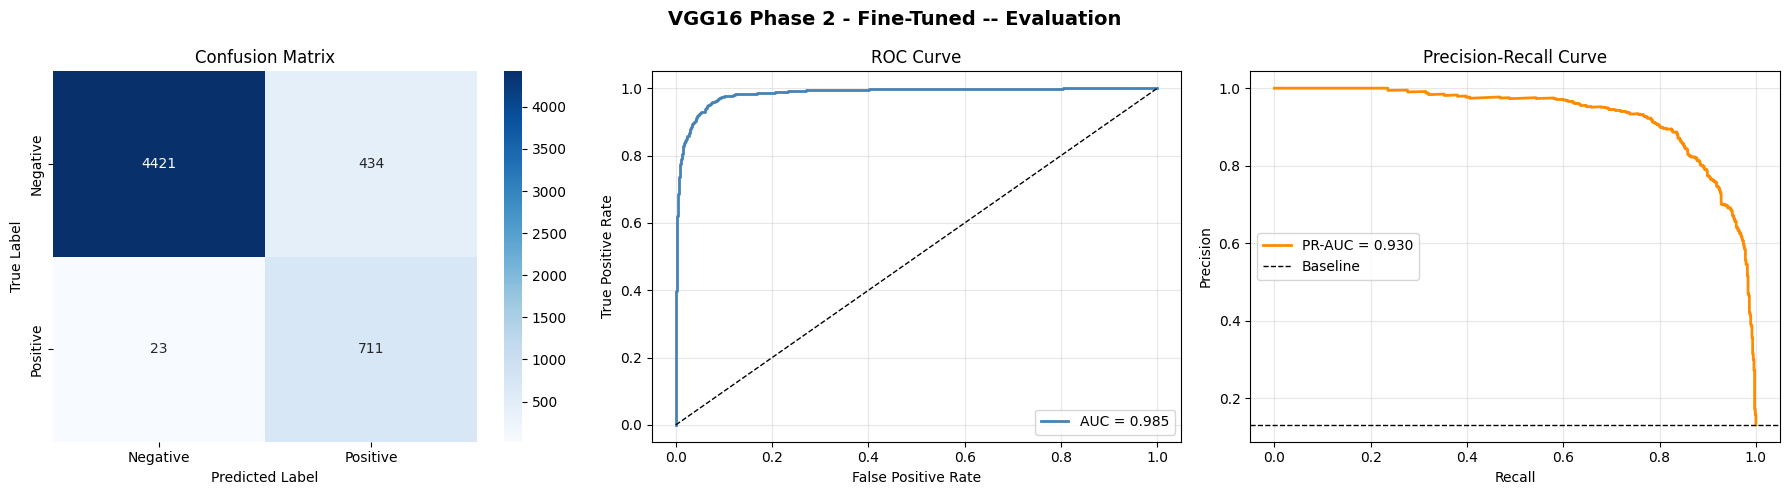

Evaluation plot saved

VGG16 PHASE 2 - FINE-TUNED SUMMARY
Accuracy:                0.918
ROC-AUC:                 0.985
Sensitivity (Positive):  0.969
Specificity (Negative):  0.911

RESULTS TRACKER
VGG16 Phase 1 - Frozen Base: Acc=0.719 | AUC=0.911 | Sens=0.941 | Spec=0.685
VGG16 Phase 2 - Fine-Tuned: Acc=0.918 | AUC=0.985 | Sens=0.969 | Spec=0.911


In [8]:
results = evaluate_experiment('VGG16 Phase 2 - Fine-Tuned',
    f'{SAVE_PATH}/vgg16_phase2_best.keras', None,
    test_dataset, SAVE_PATH, results)

## Final Results Comparison

Phase 1 vs Phase 2 compared across all metrics.
Sensitivity is the most clinically important — how many real cancer cases are caught.


FINAL RESULTS TABLE
                             accuracy  roc_auc  sensitivity  specificity
Model                                                                   
VGG16 Phase 1 - Frozen Base     0.719    0.911        0.941        0.685
VGG16 Phase 2 - Fine-Tuned      0.918    0.985        0.969        0.911


/tmp/ipykernel_55/467391549.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right', fontsize=8)
/tmp/ipykernel_55/467391549.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right', fontsize=8)
/tmp/ipykernel_55/467391549.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right', fontsize=8)
/tmp/ipykernel_55/467391549.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right', fontsize=8)


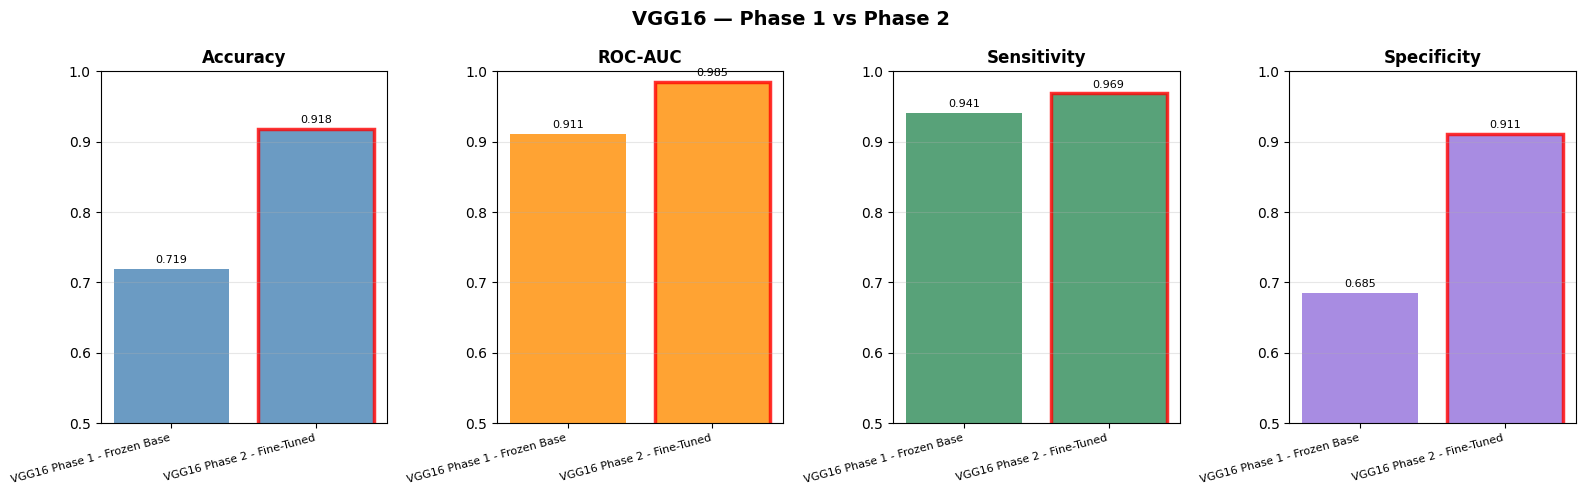

Comparison saved.


In [10]:
df = pd.DataFrame(results).T
df.index.name = 'Model'
print('\nFINAL RESULTS TABLE')
print('='*70)
print(df.to_string())

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('VGG16 — Phase 1 vs Phase 2', fontsize=14, fontweight='bold')

metrics  = ['accuracy', 'roc_auc', 'sensitivity', 'specificity']
titles   = ['Accuracy', 'ROC-AUC', 'Sensitivity', 'Specificity']
colours  = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']
names    = list(results.keys())

for ax, metric, title, colour in zip(axes, metrics, titles, colours):
    values = [results[exp][metric] for exp in names]
    bars   = ax.bar(names, values, color=colour, alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0.5, 1.0)
    ax.set_xticklabels(names, rotation=15, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    best_idx = values.index(max(values))
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(2.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/vgg16_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Comparison saved.')